In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv("heart.csv")

In [ ]:
dataset.head()
# check if the data supervised -> classification or regestration

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
dataset.info()
# check the nun value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


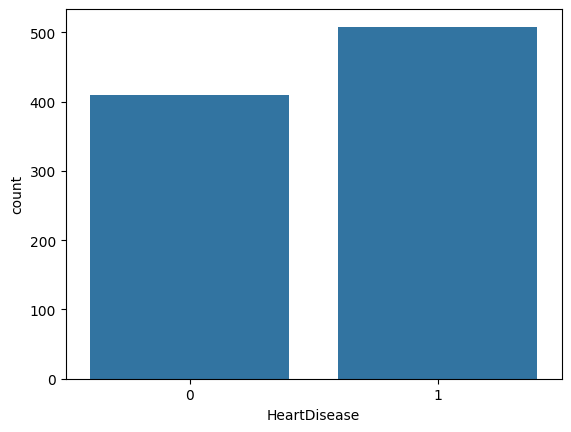

In [ ]:
sns.countplot(x=dataset['HeartDisease'])
plt.show()
# check the balance of target data to know if the model will learn on all data equaly

In [ ]:
dataset.shape

(918, 12)

In [ ]:
dataset.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [ ]:
dataset.isna().count()

,0
Age,918
Sex,918
ChestPainType,918
RestingBP,918
Cholesterol,918
FastingBS,918
RestingECG,918
MaxHR,918
ExerciseAngina,918
Oldpeak,918


In [ ]:
dataset.duplicated().sum()
# if there som data duplicated

np.int64(0)

In [ ]:
# also check balance of target data

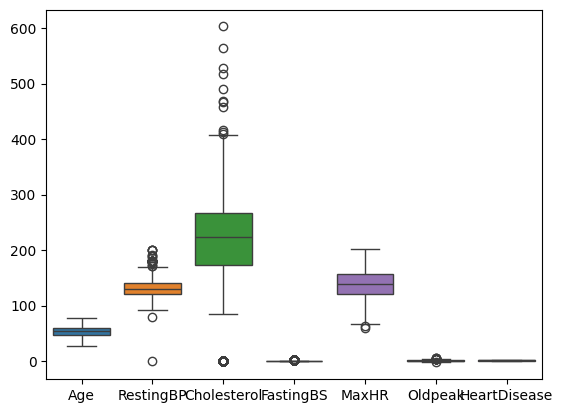

In [ ]:
sns.boxplot(data=dataset)
plt.show()
# this check of oulilers point into each col

In [ ]:
dataset['Cholesterol'].value_counts().sort_index(ascending=True)

,count
Cholesterol,
0,172
85,1
100,2
110,1
113,1
...,...
491,1
518,1
529,1


In [ ]:
# dataset['Cholesterol']= dataset['Cholesterol'].replace(0 , np.nan)
dataset.replace({'Cholesterol': {0, np.nan}}, {'RestingBP': {0, np.nan}})
#this step when there is fake data does not mean any thing in real world we replace it to nan then impute it to mean,mode,median
# When you need to replace values in multiple columns at once
# dataset.replace({'Cholesterol': {0: np.nan}, 'RestingBP': {0: np.nan}}, inplace=True)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
dataset['Cholesterol'].isna().sum()

np.int64(0)

In [ ]:
dataset['RestingBP'].isna().sum()

np.int64(0)

In [ ]:
dataset['Cholesterol']
# the pandas move on "does not shoe it in the output" the nan values so in index 0 here it is first data without nan

,Cholesterol
0,289
1,180
2,283
3,214
4,195
...,...
913,264
914,193
915,131
916,236


In [ ]:
(dataset['Cholesterol'] == 0).sum()


np.int64(172)

A **boxplot** is basically a summary of the distribution of a numeric column — it shows:

Median (middle value) — the horizontal line inside the box.

Q1 (25th percentile) — the bottom of the box (25% of the data is below this).

Q3 (75th percentile) — the top of the box (75% of the data is below this).

IQR (Interquartile Range) — Q3 − Q1 — the "height" of the box.

Whiskers — the lines extending from the box to show "normal" spread:

Lower whisker = Q1 − 1.5 × IQR

Upper whisker = Q3 + 1.5 × IQR

Outliers — dots outside the whiskers.

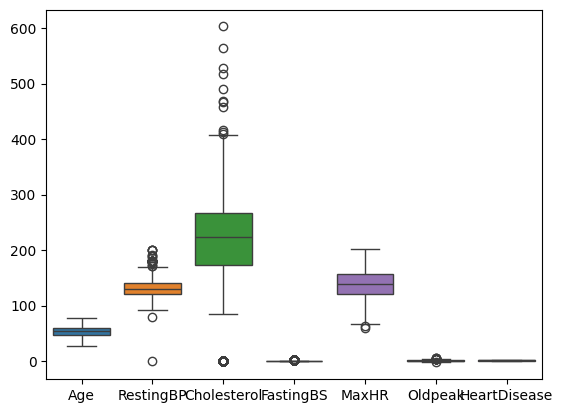

In [ ]:
sns.boxplot(data=dataset)
plt.show()

In [ ]:
dataset['RestingBP'].value_counts().sort_index()

,count
RestingBP,
0,1
80,1
92,1
94,2
95,6
...,...
180,12
185,1
190,2


In [ ]:
X = dataset.iloc[: , : -1]
y = dataset.iloc[: ,-1]

In [ ]:
X

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat


In [ ]:
y

,HeartDisease
0,0
1,1
2,0
3,1
4,0
...,...
913,1
914,1
915,1
916,1


In [ ]:
num_cols = X.select_dtypes(include=[np.number]).columns.to_list()

cat_cols = X.select_dtypes(exclude=[np.number]).columns.to_list()

In [ ]:
num_cols

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

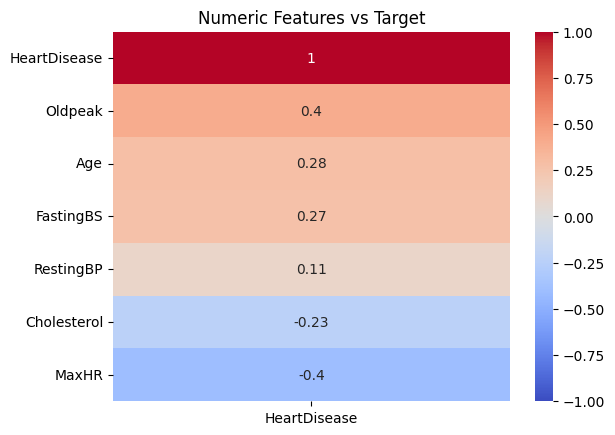

In [ ]:
corr_with_target = X[num_cols].join(y).corr()[[y.name]].sort_values(by=y.name, ascending=False)

figsize=(6, 4)
sns.heatmap(data=corr_with_target, annot=True ,vmax=1, vmin=-1 ,cmap='coolwarm')
plt.title("Numeric Features vs Target")
plt.show()

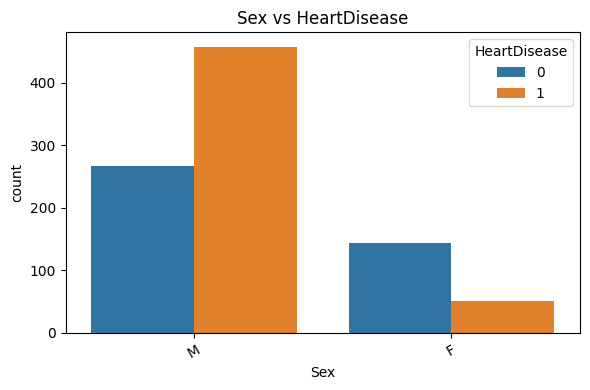

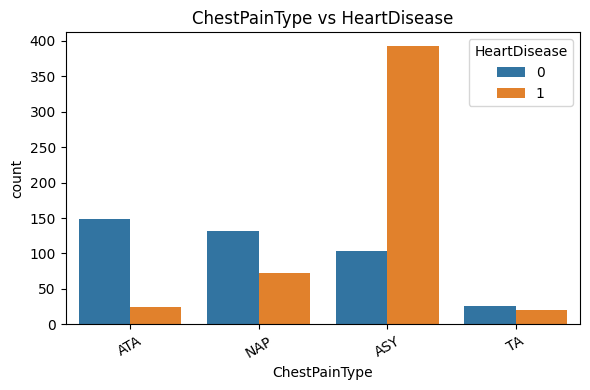

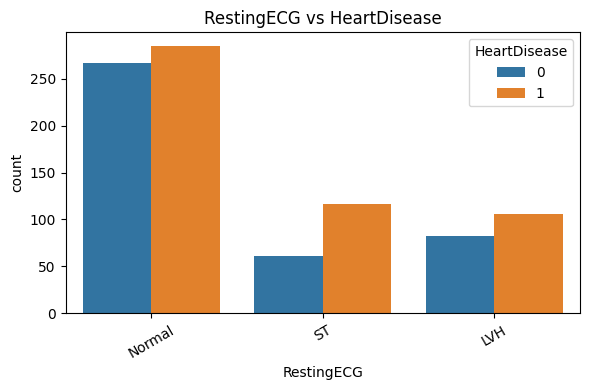

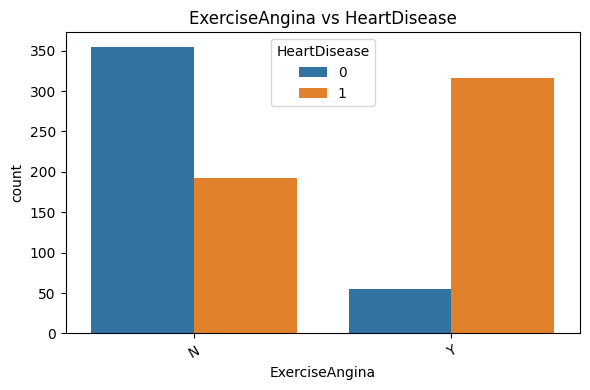

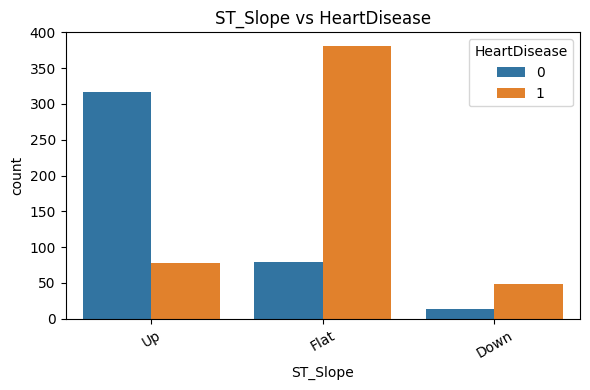

In [ ]:
target = 'HeartDisease'

for cate in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=cate , hue=target , data= dataset)
    plt.title(f"{cate} vs {target}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [ ]:
!pip install dython

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2 , random_state=0)

In [ ]:
X_train

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
378,70,M,ASY,140,0,1,Normal,157,Y,2.0,Flat
356,46,M,ASY,115,0,0,Normal,113,Y,1.5,Flat
738,65,F,NAP,160,360,0,LVH,151,N,0.8,Up
85,66,M,ASY,140,139,0,Normal,94,Y,1.0,Flat
427,59,M,ASY,140,0,0,ST,117,Y,1.0,Flat
...,...,...,...,...,...,...,...,...,...,...,...
835,54,M,ASY,110,239,0,Normal,126,Y,2.8,Flat
192,48,M,ATA,130,245,0,Normal,160,N,0.0,Up
629,57,F,ASY,128,303,0,LVH,159,N,0.0,Up
559,64,M,ASY,134,273,0,Normal,102,Y,4.0,Down


In [ ]:
X_test

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
306,55,M,ASY,115,0,1,Normal,155,N,0.1,Flat
711,66,M,ASY,120,302,0,LVH,151,N,0.4,Flat
298,51,M,ASY,110,0,1,Normal,92,N,0.0,Flat
466,55,M,NAP,120,0,0,ST,125,Y,2.5,Flat
253,62,M,ATA,140,271,0,Normal,152,N,1.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
909,63,F,ASY,124,197,0,Normal,136,Y,0.0,Flat
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat
761,52,M,ASY,112,230,0,Normal,160,N,0.0,Up
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up


In [ ]:
from sklearn.impute import SimpleImputer
impute= SimpleImputer(strategy="median")
# cols_modify= ['Cholesterol','RestingBP']
X_train[['Cholesterol', 'RestingBP']] = impute.fit_transform(X_train[['Cholesterol','RestingBP']])
X_test[['Cholesterol', 'RestingBP']] = impute.transform(X_test[['Cholesterol','RestingBP']])

In [ ]:
X_train['Cholesterol'].isna().sum()

np.int64(0)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
cat_cols= ['Sex', 'ChestPainType' , 'RestingECG', 'ExerciseAngina' , 'ST_Slope']
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
                       remainder='passthrough')

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)



In [ ]:
X_train

array([[  0. ,   1. ,   1. , ...,   1. , 157. ,   2. ],
       [  0. ,   1. ,   1. , ...,   0. , 113. ,   1.5],
       [  1. ,   0. ,   0. , ...,   0. , 151. ,   0.8],
       ...,
       [  1. ,   0. ,   1. , ...,   0. , 159. ,   0. ],
       [  0. ,   1. ,   1. , ...,   0. , 102. ,   4. ],
       [  0. ,   1. ,   0. , ...,   0. , 152. ,   0. ]])

In [ ]:
x_t = pd.DataFrame(X_train)
x_t

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,70.0,140.0,0.0,1.0,157.0,2.0
1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,46.0,115.0,0.0,0.0,113.0,1.5
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,65.0,160.0,360.0,0.0,151.0,0.8
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,66.0,140.0,139.0,0.0,94.0,1.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,59.0,140.0,0.0,0.0,117.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,54.0,110.0,239.0,0.0,126.0,2.8
730,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,48.0,130.0,245.0,0.0,160.0,0.0
731,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,57.0,128.0,303.0,0.0,159.0,0.0
732,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,64.0,134.0,273.0,0.0,102.0,4.0


In [ ]:
from sklearn.preprocessing import StandardScaler
sd = StandardScaler()


X_train[: , 14:] = sd.fit_transform(X_train[: , 14:])
X_test[: , 14:] = sd.transform(X_test[: , 14:])

In [ ]:
X_train

array([[ 0.        ,  1.        ,  1.        , ...,  1.89406969,
         0.79313997,  1.0553738 ],
       [ 0.        ,  1.        ,  1.        , ..., -0.52796368,
        -0.92450561,  0.57784676],
       [ 1.        ,  0.        ,  0.        , ..., -0.52796368,
         0.55891557, -0.0906911 ],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.52796368,
         0.87121477, -0.85473437],
       [ 0.        ,  1.        ,  1.        , ..., -0.52796368,
        -1.353917  ,  2.96548197],
       [ 0.        ,  1.        ,  0.        , ..., -0.52796368,
         0.59795297, -0.85473437]])

In [ ]:
# from sklearn.linear_model import LogisticRegression
# classifier= LogisticRegression(random_state=0)
# classifier.fit(X_train , y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier= RandomForestClassifier(n_estimators=35 ,criterion= "entropy" ,random_state=0)
classifier.fit(X_train , y_train)

RandomForestClassifier(criterion='entropy', n_estimators=35, random_state=0)

In [ ]:
# from sklearn.neighbors import KNeighborsClassifier
# classifier = KNeighborsClassifier(n_neighbors = 12, metric = "minkowski", p=2)
# classifier.fit(X_train, y_train)

# # Why your result is close to RF
# # Your dataset size is moderate and features are already scaled, so KNN can capture patterns fairly well.
# # But for larger datasets, RF usually scales better and is faster at prediction.



In [ ]:
# from sklearn.svm import SVC
# classifier= SVC(kernel='rbf', random_state=0)
# classifier.fit(X_train , y_train)

In [ ]:
pred_y = classifier.predict(X_test)
print(np.concatenate(
    (pred_y.reshape(len(pred_y), 1), y_test.to_numpy().reshape(len(y_test), 1)),
    axis=1
))


[[1 1]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [0 1]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score,recall_score
cm = confusion_matrix(y_test, pred_y)
ac =accuracy_score(y_test, pred_y)
rs=recall_score(y_test, pred_y)
rs
# recall means your model is catching about 90.65% of all the actual positive cases it means it’s better at not missing positives.

0.9065420560747663